In [1]:
%load_ext autoreload
%autoreload 2

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, classification_report, recall_score, precision_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

from mra_midas_skin_cancer_ml.utils.merge_image_pred import merge_image_pred
from mra_midas_skin_cancer_ml.utils.load_metadata_pred import load_pred_file

# Merge Prediction Results

In [3]:
# Merge image prediction results
image_pred_dfs = merge_image_pred()

for split, df in image_pred_dfs.items():
    print(f"Displaying {split} split:")
    display(df.head(3))

Length of 1ft-train key rows: 830
Length of 1ft-train pred rows: 830
Length of 1ft-train merged rows: 830
Length of 1ft-val key rows: 100
Length of 1ft-val pred rows: 100
Length of 1ft-val merged rows: 100
Length of 1ft-test key rows: 91
Length of 1ft-test pred rows: 91
Length of 1ft-test merged rows: 91
Length of 1ft combined rows: 1021
Length of 6in-train key rows: 833
Length of 6in-train pred rows: 833
Length of 6in-train merged rows: 833
Length of 6in-val key rows: 101
Length of 6in-val pred rows: 101
Length of 6in-val merged rows: 101
Length of 6in-test key rows: 94
Length of 6in-test pred rows: 94
Length of 6in-test merged rows: 94
Length of 6in combined rows: 1028
Length of dscope-train key rows: 834
Length of dscope-train pred rows: 834
Length of dscope-train merged rows: 834
Length of dscope-val key rows: 101
Length of dscope-val pred rows: 101
Length of dscope-val merged rows: 101
Length of dscope-test key rows: 93
Length of dscope-test pred rows: 93
Length of dscope-test mer

,lesion_key,midas_record_id,midas_file_name,matched_file,midas_path_binary,split,1ft_malignant_probability,1ft_prediction_label
0,1_chest_8.0x5.0,1,s-prd-398966407.jpg,s-prd-398966407.jpg,malignant,train,0.550893,malignant
1,1_l lower back_6.0x5.0,1,s-prd-398967381.jpg,s-prd-398967381.jpg,benign,train,0.606678,malignant
2,1_left upper buttock_5.0x3.0,1,s-prd-398968016.jpg,s-prd-398968016.jpg,benign,train,0.480606,malignant


Displaying 6in split:


,lesion_key,midas_record_id,midas_file_name,matched_file,midas_path_binary,split,6in_malignant_probability,6in_prediction_label
0,1_chest_8.0x5.0,1,s-prd-398966642.jpg,s-prd-398966642.jpg,malignant,train,0.583346,malignant
1,1_left upper buttock_5.0x3.0,1,s-prd-398968141.jpg,s-prd-398968141.jpg,benign,train,0.361439,benign
2,2_right upper eyelid_4.0x2.0,2,s-prd-399001840.jpg,s-prd-399001840_cropped.jpg,benign,train,0.387896,benign


Displaying dscope split:


,lesion_key,midas_record_id,midas_file_name,matched_file,midas_path_binary,split,dscope_malignant_probability,dscope_prediction_label
0,1_chest_8.0x5.0,1,s-prd-398966845.jpg,s-prd-398966845.jpg,malignant,train,0.966925,malignant
1,1_l lower back_6.0x5.0,1,s-prd-398967587.jpg,s-prd-398967587.jpg,benign,train,0.273244,benign
2,2_right upper eyelid_4.0x2.0,2,s-prd-399002046.jpg,s-prd-399002046.jpg,benign,train,0.514993,malignant


In [4]:
metadata_pred_df = load_pred_file()
metadata_pred_df.head()

,lesion_key,midas_path_binary,split,malignant_probability,metadata_prediction_label
0,1_chest_8.0x5.0,malignant,train,0.626450,malignant
1,1_l lower back_6.0x5.0,benign,train,0.478397,benign
2,1_left upper buttock_5.0x3.0,benign,test,0.586026,malignant
3,2_right upper eyelid_4.0x2.0,benign,test,0.226756,benign
4,4_left upper back_5.0x3.0,benign,train,0.276338,benign


In [5]:
def multimodal_df():
    """
    Combine the three image prediction sets and metadata predictions into a single dataframe.
    """
    fusion_df = (
        image_pred_dfs["1ft"]
            .merge(
                image_pred_dfs["6in"][[
                    "lesion_key",
                    "6in_malignant_probability"
                ]],
                on="lesion_key",
                how="inner"
            )
            .merge(
                image_pred_dfs["dscope"][[
                    "lesion_key",
                    "dscope_malignant_probability"
                ]],
                on="lesion_key",
                how="inner"
            )
            .merge(
                metadata_pred_df[[
                    "lesion_key",
                    "malignant_probability"
                ]],
                on="lesion_key",
                how="inner"
            )
    )

    cols_to_drop = [
    "midas_record_id",
    "midas_file_name",
    "matched_file",
    "1ft_prediction_label",
    ]

    fusion_df = fusion_df.drop(columns=cols_to_drop, errors="ignore")

    # Convert target to binary 0/1
    fusion_df["midas_path_binary"] = (
        fusion_df["midas_path_binary"]
            .map({"benign": 0, "malignant": 1})
    )

    print("Fusion dataframe shape:", fusion_df.shape)
    print("\nMissing values:")
    display(fusion_df.isna().sum())

    return fusion_df


# Model \#1 \- Gridsearch on Optimal Fusion Weights

In [6]:
# Load the metadata predictions

metadata_pred_df = load_pred_file()
metadata_pred_df.head()

,lesion_key,midas_path_binary,split,malignant_probability,metadata_prediction_label
0,1_chest_8.0x5.0,malignant,train,0.626450,malignant
1,1_l lower back_6.0x5.0,benign,train,0.478397,benign
2,1_left upper buttock_5.0x3.0,benign,test,0.586026,malignant
3,2_right upper eyelid_4.0x2.0,benign,test,0.226756,benign
4,4_left upper back_5.0x3.0,benign,train,0.276338,benign


In [7]:
fusion_df = multimodal_df()
fusion_df.head()

Fusion dataframe shape: (1013, 7)

Missing values:


lesion_key                      0
midas_path_binary               0
split                           0
1ft_malignant_probability       0
6in_malignant_probability       0
dscope_malignant_probability    0
malignant_probability           0
dtype: int64

,lesion_key,midas_path_binary,split,1ft_malignant_probability,6in_malignant_probability,dscope_malignant_probability,malignant_probability
0,1_chest_8.0x5.0,1,train,0.550893,0.583346,0.966925,0.626450
1,2_right upper eyelid_4.0x2.0,0,train,0.479004,0.387896,0.514993,0.226756
2,5_r dorsal hand _7.0x6.0,1,train,0.794812,0.586012,0.964949,0.683750
3,5_l dorsal hand _3.0x5.0,1,train,0.653289,0.745908,0.824787,0.672959
4,5_r forehead_5.0x4.0,0,train,0.650272,0.563458,0.843686,0.459061


In [8]:
def gridsearch_fusion_weights():
    """
    Gridsearch the optimal fusion weights by ROC AUC
    """

    prob_cols = [
        "1ft_malignant_probability",
        "6in_malignant_probability",
        "dscope_malignant_probability",
        "malignant_probability"
    ]

    y = fusion_df["midas_path_binary"]

    best_auc = 0
    best_weights = None

    for w1 in np.arange(0, 1.01, 0.1):
        for w2 in np.arange(0, 1.01 - w1, 0.1):
            for w3 in np.arange(0, 1.01 - w1 - w2, 0.1):

                w4 = 1 - w1 - w2 - w3
                weights = np.array([w1, w2, w3, w4])

                p = (fusion_df[prob_cols] * weights).sum(axis=1)

                auc = roc_auc_score(y, p)

                if auc > best_auc:
                    best_auc = auc
                    best_weights = weights

    print("Best AUC:", best_auc)
    print("Best weights:", best_weights)

    fusion_df["fusion_probability"] = (fusion_df[prob_cols] * best_weights).sum(axis=1)


In [9]:
gridsearch_fusion_weights()

Best AUC: 0.8306850874388942
Best weights: [0.1 0.3 0.4 0.2]


In [10]:
def plot_confusion_matrix(df, threshold=0.4):
    """
    Create and display confusion matrix for fusion model.
    """

    y_true = df["midas_path_binary"].astype(int)
    y_prob = df["fusion_probability"]

    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Malignant"]
    )

    disp.plot(cmap="Blues")
    plt.title("Fusion Model Confusion Matrix")
    plt.show()

    return cm


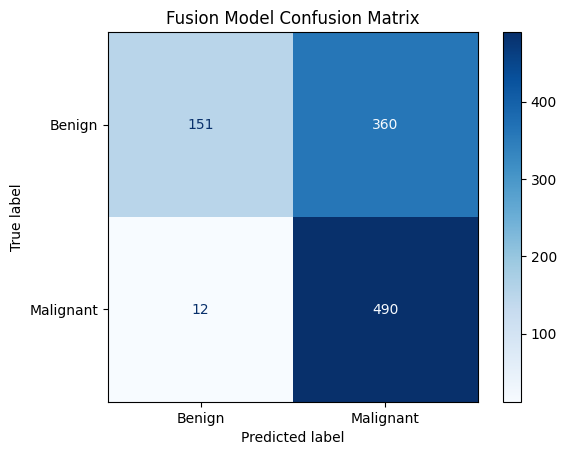

array([[151, 360],
       [ 12, 490]])

In [11]:
plot_confusion_matrix(fusion_df, threshold=0.4)

In [12]:
def evaluate_fusion(df, threshold=0.4):
    """
    Evaluate fusion model performance.
    """

    y_true = df["midas_path_binary"]
    y_prob = df["fusion_probability"]

    auc = roc_auc_score(y_true, y_prob)
    recall = recall_score(y_true, y_prob >= threshold)

    preds = (y_prob >= threshold).astype(int)

    print("ROC AUC:", auc)
    print("Recall:", recall)
    print()
    print(classification_report(y_true, preds))


In [13]:
evaluate_fusion(fusion_df, threshold=0.4)

ROC AUC: 0.8306850874388942
Recall: 0.9760956175298805

              precision    recall  f1-score   support

           0       0.93      0.30      0.45       511
           1       0.58      0.98      0.72       502

    accuracy                           0.63      1013
   macro avg       0.75      0.64      0.59      1013
weighted avg       0.75      0.63      0.59      1013



# Model \#2 \- Stacking Model

In [14]:
# Define features and target

feature_cols = [
    "1ft_malignant_probability",
    "6in_malignant_probability",
    "dscope_malignant_probability",
    "malignant_probability"  # metadata
]

X = fusion_df[feature_cols]
y = fusion_df["midas_path_binary"].values

# Out-of-fold stacking

def generate_oof_stacking(X, y, n_splits=5):
    """
    Generates out-of-fold predictions using logistic regression for stacking.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    oof_preds = np.zeros(len(X))
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train = y[train_idx]
        
        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)
        
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
        
    return oof_preds

oof_stacked_probs = generate_oof_stacking(X, y)

# Train final model

final_meta_model = LogisticRegression(max_iter=1000)
final_meta_model.fit(X, y)

fusion_df["stacked_probability"] = final_meta_model.predict_proba(X)[:, 1]

# Recall-targeted threshold

def find_threshold_for_target_recall(y_true, probs, target_recall=0.90):
    thresholds = np.linspace(0.0, 1.0, 1000)
    
    best_threshold = 0.5
    best_precision = 0
    
    for t in thresholds:
        preds = (probs >= t).astype(int)
        recall = recall_score(y_true, preds)
        
        if recall >= target_recall:
            precision = precision_score(y_true, preds, zero_division=0)
            
            if precision > best_precision:
                best_precision = precision
                best_threshold = t
                
    return best_threshold, best_precision

threshold, precision = find_threshold_for_target_recall(
    y,
    oof_stacked_probs,  
    target_recall=0.90
)

print(f"Selected Threshold: {threshold:.4f}")
print(f"Precision at Target Recall: {precision:.4f}")

# Final predictions

fusion_df["stacked_prediction"] = (
    fusion_df["stacked_probability"] >= threshold
).astype(int)

fusion_df["stacked_prediction_label"] = fusion_df["stacked_prediction"].map({
    1: "malignant",
    0: "benign"
})

# Model eval

print("\nStacked Model Performance:")
print(classification_report(y, fusion_df["stacked_prediction"]))

Selected Threshold: 0.3123
Precision at Target Recall: 0.6481

Stacked Model Performance:
              precision    recall  f1-score   support

           0       0.84      0.53      0.65       511
           1       0.65      0.90      0.75       502

    accuracy                           0.71      1013
   macro avg       0.74      0.71      0.70      1013
weighted avg       0.74      0.71      0.70      1013



<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=82a37552-7c08-4009-87b3-14968bdb21f2' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>